In [1]:
%load_ext autoreload
%autoreload 2

# Importing the modules
import os
os.environ['OMP_NUM_THREADS'] = '8' # Force the system to allocate 8 threads to OpenMP
os.environ['NGS_NUM_THREADS'] = '8' # Force NGSolve's internal task manager to use 8 threads
import ngsolve as ngs
ngs.SetNumThreads(8)

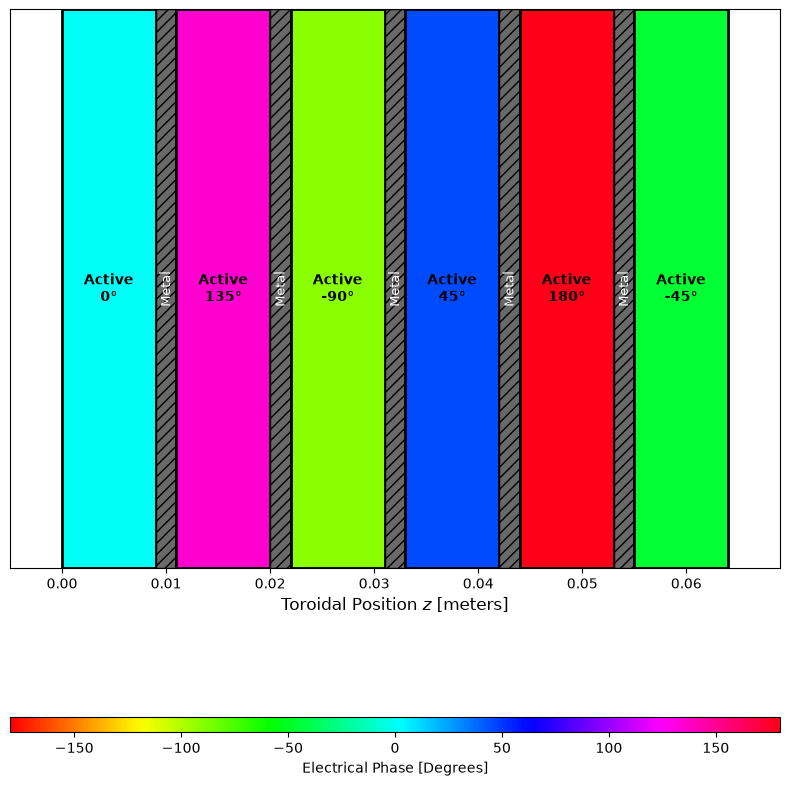

In LHCoupling class: n_para: 2.0+0.0j, n_perp_p: 2.41e+00+0.00e+00j, n_perp_m: 0.00e+00+0.00e+00j
Waveguide Medium set to: VACUUM


In [2]:
import config_dict as cfg                    # config = physical & simulation parameters 
from solver_2DHcurl_1DH1 import *            # solver = mesh build, physics import and FEM method + pmls initialization
# from solver_2DHcurl_1DH1_Copie import *
import PP_Run_and_Save as pp_run     # post process run and save = run scan function and save data in H5 files
import PP_Plot_and_Load as pp_plot   # post process load and plot = recover the sim data from H5 files and plot graphs "instantly"

import Antenna_Desc_n_Plot as antenna

geom_mode = "2D" # "1D" or "2D" 
box_medium = "PLASMA" # "VACUUM" or "PLASMA" 

antenna_grill = not None
if antenna_grill != None:
    antenna_grill = antenna.AntennaGrill(b_active=0.009, d_septa=0.002, d_gap=0.010)
    antenna_grill.add_module(num_active=6, delta_phi_deg=135, is_PAM=False)

    instructions = antenna_grill.generate_mesh_instructions()
    antenna.plot_antenna_blueprint(instructions)

solver = LHCouplingSolver_2DHcurl_1DH1(cfg.__dict__, geom_mode, box_medium, antenna_grill)

In [3]:
mesh = solver.build_mesh_with_PMLs()
solver.build_physics_Stix_B_field()

GF_E_field, Gamma_R, Gamma_T, diag_data = solver.solve_helmholtz_2DHcurl_1DH1_with_pml(mesh, geom_mode, box_medium)

geom_mode: 2D
box_medium: PLASMA
[!] MEDIUM = PLASMA, Lx_pml is set based on core lambda_perp
==== 
Lx_plasma: 5.00e-02m,   Lx_pml: 3.28e-02m,    Lx_tot: 8.28e-02m
Lx_wg = 3.00e-02m
Lz_antenna: 6.40e-02m, Lz_wall: 2.00e-02m
Lz_plasma: 6.40e-02m, Lz_pml: 4.05e-02m, Lz_tot: 1.85e-01m
==== 
n_∥: 2.0+0.0j,   λ_∥: 4.05e-02m 
n_⟂⁺ (edge): 2.41+0.00j, n_⟂⁺ (core): 7.41
λ_⟂⁺ (core): 1.09e-02m 
n_⟂-:0.00+0.00j, λ_⟂⁻: infm
==== 
n_index_meshing: 7.41 
λ_meshing (shortest): 1.09e-02m 
maxh_plasma: 1.37e-03m
==== 
ppw_pml: 20.0 
Sx_norm:1.41e+00, maxh_pml_radial: 3.86e-04 
Sz_norm_max: 1.41e+00, maxh_pml_toroidal: 3.86e-04 
maxh_pml_corner: 2.73e-04
[DOMAIN 2D DEFINED AND GLUED]


/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/solver_2DHcurl_1DH1.py:148: RuntimeWarning: divide by zero encountered in scalar divide
  self.lambda_perp_m = self.lambda0 / np.abs(self.n_perp_m)


[MESH GENERATED !]
==== 
#DoFs = 654866
len(instruction): 11
z_start: 0.02, z_end: 0.028999999999999998, E_val: (10+0j)
z_start: 0.031, z_end: 0.04, E_val: (-7.071067811865475+7.0710678118654755j)
z_start: 0.042, z_end: 0.051000000000000004, E_val: (-1.8369701987210296e-15-10j)
z_start: 0.053000000000000005, z_end: 0.062000000000000006, E_val: (7.071067811865477+7.071067811865474j)
z_start: 0.064, z_end: 0.073, E_val: (-10+3.673940397442059e-15j)
z_start: 0.075, z_end: 0.08399999999999999, E_val: (7.071067811865466-7.071067811865484j)
--- Solving the 3D vector linear system ---
==== 
w_size_R: 5.0454e-02m,    w_size_T: 3.2000e-02m
Gamma_R (SWR) = 9.964e-01
Gamma_T FAILED: Window missed or too small.

--- Poynting Flux & Energy Conservation ---
Net Power Injected (Antenna): 2.8425e-03 W/m
Net Power Exiting to PMLs:    1.7194e-03 W/m
Plasma Bulk Conservation Error: 3.95e+01 %


In [4]:
# Create the Run_XXX_XXX file in Simulation_Results folder
# run_folder = /Simulation_Results/Run_XXX
run_folder_path = pp_run.setup_output_directory("Simulation_Results", save_data=True)

# Total Run_XXX folder path to Remi's shared zone (cea intra) 
# run_folder_tot_path = "/home/remi/Perso/Stage/M2_IRFM/Codes/2D_Complete_Version/" + run_folder_path
run_folder_tot_path = '/Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/' + run_folder_path
print(f'sim_target_folder: {run_folder_tot_path}')



[SYSTEM] Output directory created: Simulation_Results/Run_20260720_161901
sim_target_folder: /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260720_161901


--- Extracting 2D Wave Map ---
Lz_plasma_src: 0.064, Lz_wall: 0.020, Lz_pml: 0.041, Lz_tot: 0.185
Bornes géométriques fixées
  --> Pure Multithreaded C++ vectorized interpolation...
In LHCoupling class: n_para: 2.0+0.0j, n_perp_p: 2.41e+00+0.00e+00j, n_perp_m: 0.00e+00+0.00e+00j
Waveguide Medium set to: VACUUM
PP_run_n_save: n_para: 2.0+0.0j, n_perp_p: 2.41e+00+0.00e+00j, n_perp_m: 0.00e+00+0.00e+00j
Params recovered
h5_path = /Home/RB286887/LH_coupling_code_remi/2D_Complete_Version/Simulation_Results/Run_20260720_161901/Wave_Map_2D.h5
type(h5_path) = <class 'str'>
oui

PRINT H5 METADATA:
 Lx_plasma: 5.00e-02
 Lx_pml: 3.28e-02
 Lx_tot: 8.28e-02
 Lz_plasma: 6.40e-02
 Lz_pml: 4.05e-02
 Lz_tot: 1.85e-01
 P_in_net: 2.84e-03
 P_out_Radial: 5.99e-07
 P_out_Toroidal: 1.72e-03
 eta_pred_R: 1.68e-02
 eta_pred_T: 1.52e-02
 eta_sim_R: 9.96e-01
 eta_sim_T: 1.00e+00
 k_para: (-155.09253162442445+0j)
 k_perp_p: (-186.8005952617502+0j)
 lambda_perp_real: 3.36e-02
 n_para_imag: 0.00e+00
 n_para_real: 

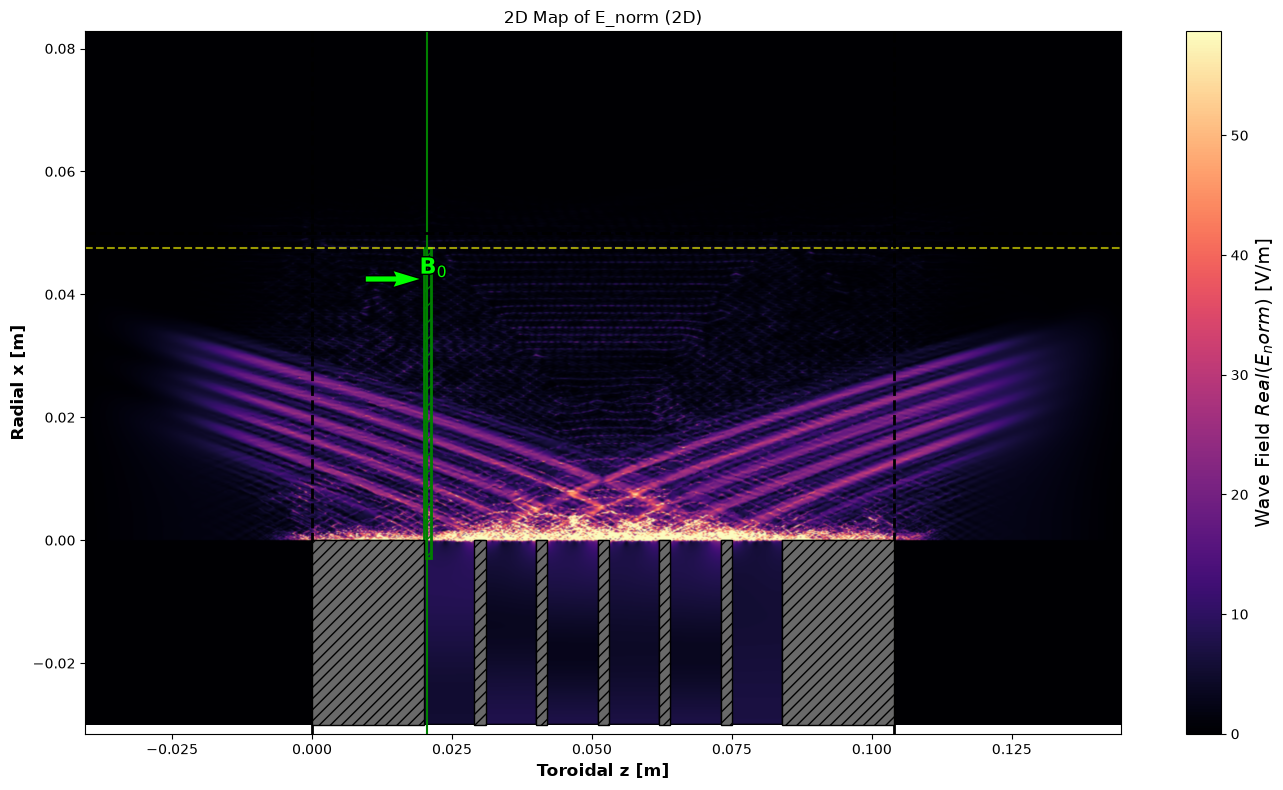

In [ ]:
E_map2D_h5_filepath = pp_run.run_2D_wave_map(mesh, GF_E_field, cfg, run_folder_tot_path, geom_mode, box_medium, antenna_grill, diag_data)
# --- Post-treatment: --- 
# Generate the H5 file for 2D map plot and save it in Run_XXX folder 
# Plot E field 2D map and save it in the same folder: Run_XXX 
Lx_wg = cfg.DOMAIN.get('Lx_wg', 0.03)
Lz_wall = cfg.DOMAIN.get('Lz_wall', 0.02)

pp_plot.plot_2D_wave_map(E_map2D_h5_filepath, run_folder_tot_path, geom_mode, component='E_norm', value_type='real',
                        antenna_grill=antenna_grill, Lx_wg=Lx_wg, Lz_wall=Lz_wall, plot_poynting=False, show_windows=False, Poynting_box=False)

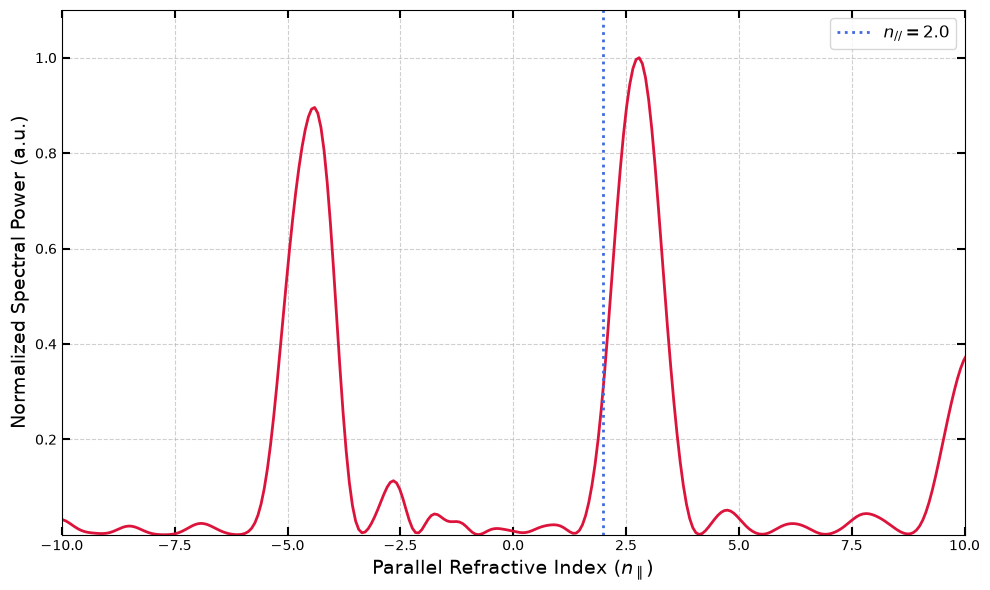

In [6]:
# Test n_para spectrum

n_para_array, power_spectrum = pp_plot.plot_n_para_spectrum(mesh, GF_E_field, cfg, geom_mode, x_eval=0.01)
